# Importing dependencies

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [20]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [21]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [22]:
figures_dir = os.path.join('./figures/')

os.system('mkdir -p ' + figures_dir)

0

# Loading the cases

In [23]:
cases = pd.read_csv('cases_validation_reavaliacao.csv')
cases = cases.rename(columns={
    'Tf_in': 'Feed temperature at the inlet (°C)',
    'Tc_in': 'Coolant temperature at the inlet (°C)',
    'P_ai gap': 'Vacuum pressure (Pa)',
    'Salinidade': 'Feed salinity at the inlet (g/L)',
    'area da membrana': 'Membrane area (m²)',
    'canais': 'Number of channels',
    'Fluxo experimental': 'Distilled water flux (L/m²h)',
    'incerteza fluxo': 'Distilled water flux uncertainty (L/m²h)',
    'Tf_out': 'Feed temperature at the outlet (°C)',
    'incerteza_tf_out': 'Feed temperature at the outlet uncertainty (°C)',
    'Tc_out': 'Coolant temperature at the outlet (°C)',
    'incerteza_tc_out': 'Coolant temperature at the outlet uncertainty (°C)',
    'Vazao': 'Flow rate (L/h)'
})

numeric_columns = [
    'Feed temperature at the inlet (°C)',
    'Coolant temperature at the inlet (°C)',
    'Vacuum pressure (Pa)',
    'Feed salinity at the inlet (g/L)',
    'Membrane area (m²)',
    'Number of channels',
    'Distilled water flux (L/m²h)',
    'Distilled water flux uncertainty (L/m²h)',
    'Feed temperature at the outlet (°C)',
    'Feed temperature at the outlet uncertainty (°C)',
    'Coolant temperature at the outlet (°C)',
    'Coolant temperature at the outlet uncertainty (°C)',
    'Flow rate (L/h)'
]
cases[numeric_columns] = cases[numeric_columns].apply(pd.to_numeric, errors='coerce')

cases['Case'] = cases['caso'].astype(str) + '-' + cases['sequencia'].astype(int).astype(str)
display(cases)


,caso,sequencia,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Flow rate (L/h),Vacuum pressure (Pa),Feed salinity at the inlet (g/L),Membrane area (m²),Number of channels,Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h),Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Case
0,10 gL,1,60.0,27.0,600,49633,10.0,12.96,6,1.50,0.1,32.0,0.1,56.0,0.5,10 gL-1
1,10 gL,2,65.0,27.0,600,49610,10.0,12.96,6,1.80,0.1,32.3,0.1,60.3,0.1,10 gL-2
2,10 gL,3,67.3,27.0,600,49638,10.0,12.96,6,1.90,0.1,32.3,0.1,62.5,0.3,10 gL-3
3,10 gL,4,69.2,27.0,600,49430,10.0,12.96,6,2.10,0.1,32.6,0.1,64.3,0.1,10 gL-4
4,10 gL,5,65.0,30.0,300,49855,10.0,12.96,6,0.90,0.1,33.6,0.7,61.8,0.3,10 gL-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,70.1 gL,17,80.0,20.0,750,81325,70.1,25.92,12,1.91,NaN,NaN,NaN,74.6,NaN,70.1 gL-17
127,70.1 gL,18,80.0,30.0,750,81325,70.1,25.92,12,1.66,NaN,NaN,NaN,75.7,NaN,70.1 gL-18
128,70.1 gL,19,80.0,20.0,800,81325,70.1,25.92,12,2.04,NaN,NaN,NaN,74.0,NaN,70.1 gL-19
129,70.1 gL,20,80.0,30.0,800,81325,70.1,25.92,12,1.76,NaN,NaN,NaN,74.8,NaN,70.1 gL-20


# Running the cases

In [24]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [25]:
results = pd.DataFrame(columns=[
    'Case', 'Salinity (g/L)', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 
    'Hot feedwater outlet temperature (°C)', 'Exp. hot feedwater outlet temperature (°C)', 
    'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = -abs(elem['Vacuum pressure (Pa)'])

    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(
        salinity_equation,
        initial_guess,
        args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)'])
    )[0]
    cool_salinity = feed_salinity

    flow_rate = elem['Flow rate (L/h)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * flow_rate / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * flow_rate / 3600000.0

    membrane_area = elem['Membrane area (m²)']
    number_channels = int(elem['Number of channels'])

    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(cool_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels))

    results_file = pd.read_csv('./results/report.csv')
    latest_result = results_file.iloc[-1]

    mass_flux = latest_result.iloc[11]
    film_temperature = latest_result.iloc[4]
    hot_feedwater_outlet_temperature = latest_result.iloc[1]
    cold_feedwater_outlet_temperature = latest_result.iloc[2]
    heat_flux = latest_result.iloc[13]
    vapor_heat_flux = latest_result.iloc[15]
    GOR = latest_result.iloc[17]
    STECth = latest_result.iloc[19]
    thermal_efficiency = latest_result.iloc[18]

    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Salinity (g/L)': elem['Feed salinity at the inlet (g/L)'], # <-- ADICIONADO AQUI
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)


Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  10.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =  35.0  g/L
Salinity =

In [26]:
display(results)

,Case,Salinity (g/L),Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,10 gL-1,10.0,1.47648,1.5,32.569399,32.0,54.061639,56.0,1442.897165,961.491871,3.034673,214.781286,66.636202
1,10 gL-2,10.0,1.785266,1.8,33.110066,32.3,58.377401,60.3,1673.021158,1157.977255,3.275924,198.203873,69.214741
2,10 gL-3,10.0,1.933802,1.9,33.335106,32.3,60.376531,62.5,1779.630948,1252.022756,3.387327,191.345354,70.352944
3,10 gL-4,10.0,2.056781,2.1,33.517454,32.6,62.026841,64.3,1867.646207,1329.615325,3.471362,186.438247,71.192034
4,10 gL-5,10.0,0.891846,0.9,33.282857,33.6,61.232883,61.8,831.981336,578.167539,5.755094,112.703967,69.49285
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,70.1 gL-17,70.1,2.167058,1.91,25.616808,NaN,72.791663,74.6,1718.918492,1304.960318,5.536139,108.878364,75.917522
127,70.1 gL-18,70.1,1.841518,1.66,34.600351,NaN,74.222672,75.7,1436.597509,1102.872018,5.855562,102.365062,76.769729
128,70.1 gL-19,70.1,2.314441,2.04,25.880668,NaN,72.53737,74.0,1824.64508,1393.312645,5.3528,112.580843,76.360749
129,70.1 gL-20,70.1,1.969632,1.76,34.806382,NaN,74.022945,74.8,1525.427679,1179.312573,5.674008,105.619209,77.310291


In [27]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0      -1.567995
1      -0.818583
2       1.779065
3      -2.058041
4      -0.906024
         ...    
126    13.458527
127    10.934826
128    13.452973
129    11.910886
130    11.982341
Length: 131, dtype: object

# Plot the results for different salinities

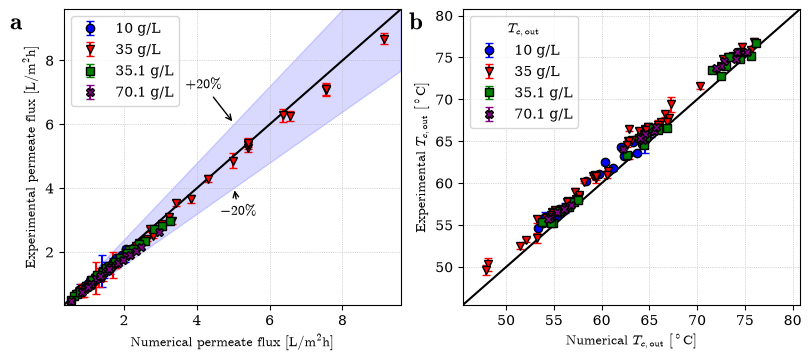

In [30]:
# %% [markdown]
# # Plot the results for different salinities

# %%
# --- EXTRAÇÃO DE DADOS ---
salinity = pd.to_numeric(cases['Feed salinity at the inlet (g/L)'], errors='coerce').to_numpy(dtype=float)

flux_x = pd.to_numeric(results['Permeate flux (L/m²h)'], errors='coerce').to_numpy(dtype=float)
flux_y = pd.to_numeric(results['Exp. permeate flux (L/m²h)'], errors='coerce').to_numpy(dtype=float)
flux_err = pd.to_numeric(cases['Distilled water flux uncertainty (L/m²h)'], errors='coerce').to_numpy(dtype=float)

cold_x = pd.to_numeric(results['Cold feedwater outlet temperature (°C)'], errors='coerce').to_numpy(dtype=float)
cold_y = pd.to_numeric(results['Exp. cold feedwater outlet temperature (°C)'], errors='coerce').to_numpy(dtype=float)
cold_err = pd.to_numeric(cases['Coolant temperature at the outlet uncertainty (°C)'], errors='coerce').to_numpy(dtype=float)

# Máscaras de valores válidos
flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y)
cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y)

# Limites dos eixos
if flux_mask.sum() > 0:
    min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
    max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
else:
    min_mass_flux, max_mass_flux = 0.0, 10.0

temperature_values = np.concatenate([cold_x[cold_mask], cold_y[cold_mask]])
if len(temperature_values) > 0:
    min_temperature = 0.95 * np.nanmin(temperature_values)
    max_temperature = 1.05 * np.nanmax(temperature_values)
else:
    min_temperature, max_temperature = 0.0, 100.0

mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

# --- PLOTAGEM ---
figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# Identifica as salinidades únicas ordenadas
unique_salinities = np.sort(np.unique(salinity[~np.isnan(salinity)]))

# Loop para plotar cada salinidade com um marcador e cor distintos
for i, sal in enumerate(unique_salinities):
    sal_filter = (salinity == sal)
    
    m_flux = flux_mask & sal_filter
    m_cold = cold_mask & sal_filter
    
    current_marker = markers[i % len(markers)]
    current_color = colors[i % len(colors)]
    label_text = f'{sal:g} g/L'

    # Gráfico 1: Fluxo
    if m_flux.sum() > 0:
        axsval[0].errorbar(
            flux_x[m_flux],
            flux_y[m_flux],
            yerr=flux_err[m_flux],
            marker=current_marker, markersize=marker_size, markeredgecolor='black',
            color=current_color, capsize=cap_size, linestyle='None',
            label=label_text
        )

    # Gráfico 2: Temperatura (Cold)
    if m_cold.sum() > 0:
        axsval[1].errorbar(
            cold_x[m_cold],
            cold_y[m_cold],
            yerr=cold_err[m_cold],
            marker=current_marker, markersize=marker_size, markeredgecolor='black',
            color=current_color, capsize=cap_size, linestyle='None',
            label=label_text
        )

# Linhas de referência 1:1 e intervalo de ±20%
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.15)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-35, 25), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

axsval[1].plot(temperature_line, temperature_line, color='black')

# Configurações do Gráfico 1 (Fluxo)
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')
axsval[0].legend(fontsize=fontsize_legend, loc='upper left')

# Configurações do Gráfico 2 (Temperatura Tc,out)
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)
axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical}\ T_{c,\mathrm{out}}\ [^\circ\mathrm{C}]$')
axsval[1].set_ylabel(r'$\mathrm{Experimental}\ T_{c,\mathrm{out}}\ [^\circ\mathrm{C}]$')
axsval[1].legend(title=r'$T_{c,\mathrm{out}}$', title_fontsize=fontsize_legend, fontsize=fontsize_legend, loc='upper left')

# Rótulos (a) e (b)
axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

In [29]:
# Quantidade de pontos no gráfico de fluxo de permeado (Gráfico a)
qtd_fluxo = flux_mask.sum()
print(f"Pontos plotados no gráfico de fluxo de permeado: {qtd_fluxo}")

# Quantidade de pontos no gráfico de temperatura (Gráfico b)
qtd_cold = cold_mask.sum()
print(f"Pontos Tc,out plotados no gráfico de temperatura: {qtd_cold}")

Pontos plotados no gráfico de fluxo de permeado: 131
Pontos Tc,out plotados no gráfico de temperatura: 131
